# Parte 5: Analisis Descriptivo del Dataset Integrado
## Riesgo de Contaminación por Nitratos | La Rioja, 2015 - 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
ruta = r"C:\Users\mcangulo\OneDrive - FEDERACION DE EMPRESAS DE LA RIOJA\Escritorio\dataset_larioja\9_dataset_final\dataset_final_integrado_larioja_2015_2025.xlsx"

df = pd.read_excel(ruta)

print("Dataset cargado correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Dataset cargado correctamente
Filas: 1173
Columnas: 105


### 1. Analisis de Caracteristicas

> **Tabla Nº1.** Características generales del dataset

In [3]:
info_general = pd.DataFrame({
    "Característica": [
        "Número de observaciones",
        "Número de variables",
        "Número de puntos IPA únicos",
        "Año mínimo",
        "Año máximo",
        "Variable hidroquímica principal",
        "Unidad de análisis",
        "Tipo de problema"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        df["ipa"].nunique() if "ipa" in df.columns else np.nan,
        df["anio"].min() if "anio" in df.columns else np.nan,
        df["anio"].max() if "anio" in df.columns else np.nan,
        "no3_mgl",
        "Punto IPA – fecha de muestreo",
        "Clasificación del riesgo de contaminación"
    ]
})

display(info_general)

,Característica,Valor
0,Número de observaciones,1173
1,Número de variables,105
2,Número de puntos IPA únicos,101
3,Año mínimo,2015
4,Año máximo,2025
5,Variable hidroquímica principal,no3_mgl
6,Unidad de análisis,Punto IPA – fecha de muestreo
7,Tipo de problema,Clasificación del riesgo de contaminación


*Interpretación:*
El dataset final contiene 1.173 observaciones correspondientes a 101 puntos de monitoreo únicos, distribuidas entre los años 2015 y 2025. Cada observación representa la concentración de nitratos medida en un punto IPA y una fecha de muestreo específica.


> **Tabla Nº2.** Estadisticos descriptivos de nitratos

In [4]:
estadisticos_no3 = df["no3_mgl"].describe().to_frame().reset_index()
estadisticos_no3.columns = ["Estadístico", "Valor"]
estadisticos_no3["Valor"] = estadisticos_no3["Valor"].round(2)

display(estadisticos_no3)

# Percentiles útiles
percentiles_no3 = df["no3_mgl"].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).reset_index()
percentiles_no3.columns = ["Percentil", "Valor mg/L NO3"]
percentiles_no3["Valor mg/L NO3"] = percentiles_no3["Valor mg/L NO3"].round(2)

display(percentiles_no3)

,Estadístico,Valor
0,count,1173.00
1,mean,51.80
2,std,48.01
3,min,0.10
4,25%,13.02
5,50%,38.70
6,75%,79.00
7,max,297.00


,Percentil,Valor mg/L NO3
0,0.10,3.67
1,0.25,13.02
2,0.50,38.70
3,0.75,79.00
4,0.90,118.00
5,0.95,142.40


*Interpretación:*

La media es 51,80, pero la mediana es 38,70. Como la media es mayor que la mediana, significa que existen valores muy altos que empujan el promedio hacia arriba. La mayoría de valores no son tan extremos, pero hay algunos puntos con concentraciones muy altas que elevan la media.

El percentil sirve para saber cómo se distribuyen los datos. Te dice que hay un grupo pequeño, pero importante, con valores muy elevados de nitratos. lo cual confirma que el problema no es uniforme: hay zonas o puntos con mucha mayor contaminación.

Percentil 95 = 142,40
El 5% de los datos supera 142,40 mg/L.

> **Tabla Nº3.** Distribución de clases de riesgo

In [5]:
def clasificar_no3(valor):
    if pd.isna(valor):
        return np.nan
    elif valor < 25:
        return "normal"
    elif valor <= 37.5:
        return "riesgo"
    else:
        return "afectada"

df["clase_calculada"] = df["no3_mgl"].apply(clasificar_no3)

tabla_clases = df["clase_calculada"].value_counts().reset_index()
tabla_clases.columns = ["Clase", "Observaciones"]
tabla_clases["Porcentaje"] = (tabla_clases["Observaciones"] / len(df) * 100).round(2)

orden = ["normal", "riesgo", "afectada"]
tabla_clases["orden"] = tabla_clases["Clase"].map({c: i for i, c in enumerate(orden)})
tabla_clases = tabla_clases.sort_values("orden").drop(columns="orden")

display(tabla_clases)

,Clase,Observaciones,Porcentaje
1,normal,410,34.95
2,riesgo,172,14.66
0,afectada,591,50.38


*Interpretación:*
La clase más grande es afectada, con 50,38%. Eso quiere decir que más de la mitad de tus observaciones superan el umbral de afectación que estás usando.
La clase más pequeña es riesgo, con 14,66%. Esto puede ser un problema para el modelo porque tiene menos ejemplos para aprender esa categoría.

> **Tabla Nº4.** Verificación de consistencia entre clase original y clase calculada

In [6]:
if "clase" in df.columns:
    comparacion_clase = pd.crosstab(
        df["clase"],
        df["clase_calculada"],
        rownames=["Clase original"],
        colnames=["Clase calculada"]
    )

    display(comparacion_clase)

    coincidencia = (df["clase"].astype(str).str.lower() == df["clase_calculada"].astype(str).str.lower()).mean() * 100
    print("Porcentaje de coincidencia entre clase original y clase calculada:", round(coincidencia, 2), "%")
else:
    print("No existe la columna 'clase' en el dataset.")

Clase calculada,afectada,normal,riesgo
Clase original,,,
afectada,591,0,0
normal,0,410,0
riesgo,0,0,172


Porcentaje de coincidencia entre clase original y clase calculada: 100.0 %


*Interpetación:*
Se verificó la consistencia de la variable objetivo recalculando las clases a partir de la concentración de nitratos. La comparación entre la clase original y la clase calculada mostró una coincidencia del 100%, confirmando la correcta construcción del target.

> **Tabla Nº5.** Resumen anual de concentración de nitratos

In [7]:
resumen_anual = df.groupby("anio").agg(
    Observaciones=("no3_mgl", "count"),
    Media_NO3=("no3_mgl", "mean"),
    Mediana_NO3=("no3_mgl", "median"),
    Minimo_NO3=("no3_mgl", "min"),
    Maximo_NO3=("no3_mgl", "max"),
    Desv_Estandar=("no3_mgl", "std")
).reset_index()

resumen_anual = resumen_anual.round(2)

display(resumen_anual)

,anio,Observaciones,Media_NO3,Mediana_NO3,Minimo_NO3,Maximo_NO3,Desv_Estandar
0,2015,106,69.73,62.15,0.1,247.0,61.24
1,2016,112,57.15,42.85,0.1,297.0,57.79
2,2017,112,51.35,34.90,1.8,192.0,45.49
3,2018,50,65.94,63.75,1.0,148.1,34.75
4,2019,109,54.66,44.70,2.5,208.0,41.74
5,2020,96,58.86,48.00,2.5,243.0,48.56
6,2021,118,44.36,31.00,2.5,228.0,45.39
7,2022,79,49.45,39.00,2.5,210.0,46.31
8,2023,120,41.63,29.50,2.5,198.0,40.90
9,2024,66,47.12,32.60,2.5,195.0,44.68


*Interpretación:*
Se observa una disminución descriptiva de las medias anuales en los últimos años, pero esta tendencia debe interpretarse con cautela por la frecuencia irregular de muestreo. 

> **Tabla Nº6.** Concentración de nitratos según zona vulnerable

In [8]:
resumen_zona = df.groupby("zona_vulnerable_nitratos").agg(
    Observaciones=("no3_mgl", "count"),
    Media_NO3=("no3_mgl", "mean"),
    Mediana_NO3=("no3_mgl", "median"),
    Minimo_NO3=("no3_mgl", "min"),
    Maximo_NO3=("no3_mgl", "max"),
    Desv_Estandar=("no3_mgl", "std")
).reset_index()

resumen_zona["zona_vulnerable_nitratos"] = resumen_zona["zona_vulnerable_nitratos"].map({
    False: "Fuera de zona vulnerable",
    True: "Dentro de zona vulnerable"
})

resumen_zona = resumen_zona.round(2)

display(resumen_zona)

,zona_vulnerable_nitratos,Observaciones,Media_NO3,Mediana_NO3,Minimo_NO3,Maximo_NO3,Desv_Estandar
0,Fuera de zona vulnerable,548,20.55,13.01,0.1,140.9,20.77
1,Dentro de zona vulnerable,625,79.21,69.80,0.1,297.0,48.38


*Interpretación:*
La comparación según zona vulnerable muestra una clara diferenciación territorial. Las observaciones ubicadas dentro de zonas vulnerables presentan concentraciones medias y medianas de nitratos considerablemente superiores a las observadas fuera de dichas zonas.

Existe una asociación entre pertenecer a zona vulnerable y presentar mayores concentraciones de nitratos.
Porque la zona vulnerable es una categoría territorial definida precisamente por problemas o riesgos asociados a nitratos. Entonces puede funcionar como una variable muy predictiva, pero también puede ser una especie de “atajo” para el modelo.

**Nota**

Tener en cuenta que se deberia realizar una práctica probando los modelos:

* con zona_vulnerable_nitratos;

* sin zona_vulnerable_nitratos.

Así evaluas si el modelo depende demasiado de esa variable.

> **Tabla Nº7.** Valores faltantes

In [9]:
tabla_nulos = pd.DataFrame({
    "Variable": df.columns,
    "Valores nulos": df.isna().sum().values,
    "Porcentaje": (df.isna().sum().values / len(df) * 100).round(2)
})

tabla_nulos = tabla_nulos[tabla_nulos["Valores nulos"] > 0]
tabla_nulos = tabla_nulos.sort_values("Porcentaje", ascending=False)

display(tabla_nulos)

,Variable,Valores nulos,Porcentaje
9,localidad,464,39.56
5,cota,426,36.32
55,soil_phh2o_0_5cm,82,6.99
56,soil_phh2o_15_30cm,82,6.99
57,soil_phh2o_5_15cm,82,6.99
74,clc2012_nombre,12,1.02
77,clc2018_nombre,12,1.02
31,precip_30d,1,0.09
33,temp_media_30d,1,0.09


*Interpretación:*
Tu dataset no está perfecto, pero está bastante bien. Los nulos importantes están concentrados en pocas columnas.

**Nota:**

* localidad	- Usar solo descriptivamente o excluir del modelo
* cota - Excluir o reemplazar por altitud_dem_m
* pH SoilGrids -	Imputar con mediana
* CLC nombres -	Usar códigos, no nombres
* precip_30d / temp_media_30d	- Imputar o eliminar esa fila

> **Corrección de coherencia (auditoría posterior, verificada con outputs reales):** la versión original de esta celda calculaba `df.select_dtypes(include=[np.number])` directamente sobre el dataset crudo de 105 columnas, sin excluir antes los identificadores ni las coordenadas duplicadas generadas por los merges de Parte 4. Como consecuencia, el "Top 15 positivas" original tenía **la misma variable (coordenada Y del punto) repetida 5 veces** bajo distintos nombres (`y_utm30_esp`, `y_utm30`, `lat_x`, `lat_y`, `latitud`, todas con r≈0,31), y el "Top 15 negativas" incluía `ipa` (el identificador numérico del punto, r=-0,228) — una correlación sin ningún significado físico, ya que `ipa` es un número arbitrario, no una condición ambiental.
>
> Se corrige excluyendo explícitamente los identificadores, las coordenadas duplicadas y las variables de fuga directa del target antes de calcular la matriz de correlación, de forma análoga a la lista curada que ya se usa correctamente en el heatmap de Parte 6.

> **Tabla Nº8.** Correlaciones exploratorias con no3_mgl

In [10]:
# Identificadores, duplicados de coordenadas y variables de fuga directa:
# se excluyen para que la tabla de correlaciones no quede dominada por
# columnas redundantes (mismo punto repetido bajo distintos nombres) ni
# por identificadores sin significado ambiental (ver nota de corrección).
cols_excluir_corr = {
    'ipa', 'codigo_masa_agua',
    'x_utm30_esp', 'y_utm30_esp', 'lat_y', 'lon_y',   # duplicados de coordenadas del punto
    'latitud', 'longitud',                              # coordenadas de la ESTACIÓN climática, no del punto
    'anio_clima', 'mes_clima',                          # redundantes con anio/mes de la observación
    'clc2012_codigo', 'clc2018_codigo',                 # códigos brutos, redundantes con *_nombre
    'afectada', 'en_riesgo',                            # fuga directa: construidas a partir de no3_mgl
    *[c for c in df.columns if re.fullmatch(r'ndvi_20\d{2}', c)],  # NDVI anual en bruto (fuga temporal)
}
cols_excluir_corr = [c for c in cols_excluir_corr if c in df.columns]

df_num = df.select_dtypes(include=[np.number]).drop(columns=cols_excluir_corr, errors='ignore')

correlaciones = df_num.corr(numeric_only=True)["no3_mgl"].sort_values(ascending=False).reset_index()
correlaciones.columns = ["Variable", "Correlación con NO3"]

correlaciones = correlaciones[correlaciones["Variable"] != "no3_mgl"]

print(f"Variables excluidas de la correlación: {len(cols_excluir_corr)}")
print("Top 15 correlaciones positivas:")
display(correlaciones.head(15).round(3))

print("Top 15 correlaciones negativas:")
display(correlaciones.tail(15).round(3))


Variables excluidas de la correlación: 25
Top 15 correlaciones positivas:


,Variable,Correlación con NO3
1,y_utm30,0.316
2,lat_x,0.316
3,soil_phh2o_5_15cm,0.174
4,soil_phh2o_15_30cm,0.174
5,soil_phh2o_0_5cm,0.160
6,sigpac_pendiente_pct,0.135
7,soil_clay_5_15cm,0.078
8,ndvi_cambio_periodo,0.066
9,soil_clay_0_5cm,0.055
10,soil_clay_15_30cm,0.045


Top 15 correlaciones negativas:


,Variable,Correlación con NO3
37,altitud_dem_m,-0.117
38,soil_wv0033_15_30cm,-0.126
39,soil_cec_15_30cm,-0.138
40,soil_soc_15_30cm,-0.140
41,anio,-0.144
42,soil_cec_5_15cm,-0.157
43,soil_cec_0_5cm,-0.163
44,dist_estacion_m,-0.177
45,soil_sand_15_30cm,-0.185
46,soil_sand_0_5cm,-0.192


*Interpretacion:*
Las variables más **correlacionadas positivamente** son espaciales: coordenada Y y latitud.
Eso significa que los nitratos parecen aumentar hacia una determinada dirección espacial, probablemente hacia ciertas zonas de La Rioja.
También aparecen correlaciones positivas con pH del suelo y pendiente SIGPAC, pero son más bajas.
Una correlación de 0.31 no es altísima. Es moderada-baja. Pero en datos ambientales es normal que las relaciones no sean extremadamente fuertes, porque el fenómeno depende de muchas variables a la vez.

Las **correlaciones negativas** indican que, cuando esa variable aumenta, los nitratos tienden a bajar. A medida que algunas variables aumentan, los nitratos tienden a bajar. Pero no prueban causa. Solo muestran asociación.

**ANALISIS FINAL:**

1. El dataset tiene tamaño suficiente - 1173 observaciones y 101 puntos es una base razonable para un TFM.

2. Los nitratos están muy dispersos - Hay valores muy bajos y valores muy altos. Esto refleja un fenómeno ambiental desigual.

3. La clase afectada es la más frecuente - El 50,38% de las observaciones están afectadas según el umbral >37,5 mg/L.

4. La zona vulnerable diferencia muy bien los niveles de nitratos - Dentro de zona vulnerable los nitratos son mucho más altos que fuera.

5. Hay patrón espacial - Las coordenadas aparecen entre las variables más correlacionadas, lo que sugiere que la contaminación tiene una distribución territorial marcada.

### 2. Figuras para analisis descriptivo

In [11]:
plt.style.use('default')

> **Figura Nº1.** Histograma de nitratos y umbrales

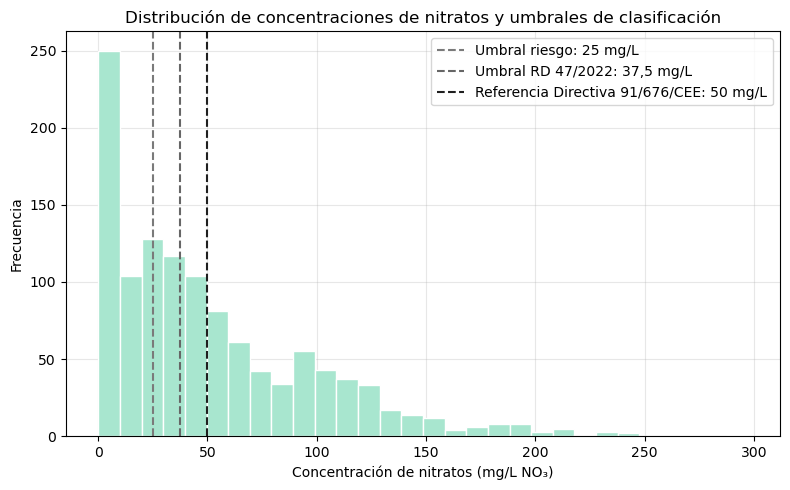

Guardado: ad_distribucion.png


In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["no3_mgl"].dropna(), bins=30, color="#A8E6CF", edgecolor="white")

plt.axvline(25, color="#7A7A7A", linestyle="--", linewidth=1.5,
            label="Umbral riesgo: 25 mg/L")

plt.axvline(37.5, color="#666666", linestyle="--", linewidth=1.5,
            label="Umbral RD 47/2022: 37,5 mg/L")

plt.axvline(50, color="#1F1F1F", linestyle="--", linewidth=1.5,
            label="Referencia Directiva 91/676/CEE: 50 mg/L")

plt.grid(True, alpha=0.3)
plt.gca().set_axisbelow(True)
plt.xlabel("Concentración de nitratos (mg/L NO₃)")
plt.ylabel("Frecuencia")
plt.title("Distribución de concentraciones de nitratos y umbrales de clasificación")
plt.legend()
plt.tight_layout()

plt.savefig('ad_distribucion.png')
plt.show()

print('Guardado: ad_distribucion.png')

**Interpretacion**

La distribución de nitratos presenta una concentración importante de observaciones en valores bajos y moderados, pero también una cola hacia valores elevados, con registros superiores a 100 mg/L. Las líneas verticales permiten visualizar los umbrales utilizados para diferenciar las clases normal, riesgo y afectada, así como la referencia europea de 50 mg/L.


Sirve para mostrar:

* cómo se distribuyen las concentraciones de nitratos

* que hay muchos valores bajos, pero también valores muy altos

* que la distribución es asimétrica hacia la derecha

* dónde caen los umbrales de 25, 37,5 y 50 mg/L.

> **Figura Nº2.** Evolución anual de nitratos

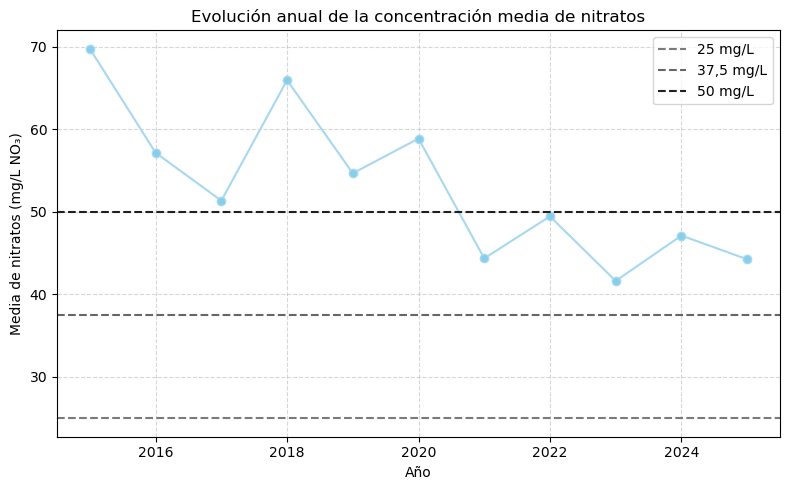

Guardado: ad_evolucion.png


In [13]:
media_anual = df.groupby("anio")["no3_mgl"].mean()

plt.figure(figsize=(8, 5))
plt.plot(media_anual.index, media_anual.values, color="#A7D8F0", marker="o", markerfacecolor="#87CEEB")

plt.axhline(25, color="#7A7A7A", linestyle="--", label="25 mg/L")
plt.axhline(37.5, color="#666666", linestyle="--", label="37,5 mg/L")
plt.axhline(50,color="#1F1F1F",  linestyle="--", label="50 mg/L")


plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Año")
plt.ylabel("Media de nitratos (mg/L NO₃)")
plt.title("Evolución anual de la concentración media de nitratos")
plt.legend()
plt.tight_layout()

plt.savefig('ad_evolucion.png')
plt.show()

print('Guardado: ad_evolucion.png')

**Interpretación**

La concentración media anual muestra valores superiores a 50 mg/L en varios años del periodo inicial, especialmente 2015, 2018 y 2020. A partir de 2021 se observan valores medios inferiores, aunque esta evolución debe interpretarse con cautela debido a la frecuencia irregular de muestreo y al distinto número de observaciones por año.

> **Figura Nº3.** Boxplot por zona vulnerable

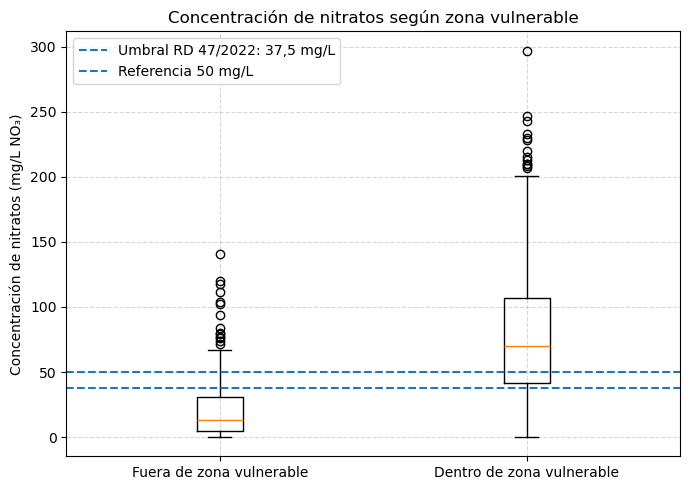

Guardado: ad_concentracioneszv.png


In [14]:
datos_fuera = df[df["zona_vulnerable_nitratos"] == False]["no3_mgl"].dropna()
datos_dentro = df[df["zona_vulnerable_nitratos"] == True]["no3_mgl"].dropna()

plt.figure(figsize=(7, 5))

plt.boxplot(
    [datos_fuera, datos_dentro],
    tick_labels=["Fuera de zona vulnerable", "Dentro de zona vulnerable"]
)

plt.axhline(37.5, linestyle="--", label="Umbral RD 47/2022: 37,5 mg/L")
plt.axhline(50, linestyle="--", label="Referencia 50 mg/L")

plt.grid(True, linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)

plt.ylabel("Concentración de nitratos (mg/L NO₃)")
plt.title("Concentración de nitratos según zona vulnerable")
plt.legend()
plt.tight_layout()

plt.savefig("ad_concentracioneszv.png", dpi=300, bbox_inches="tight")
plt.show()

print("Guardado: ad_concentracioneszv.png")

**Interpretación:**

Las observaciones ubicadas dentro de zonas vulnerables presentan concentraciones de nitratos claramente superiores a las observadas fuera de estas zonas. Esto respalda la coherencia territorial del dataset, aunque la relación debe interpretarse como asociación espacial y no como causalidad directa.


Se ve claro que:

* fuera de zona vulnerable, la mediana es baja;
* dentro de zona vulnerable, la mediana está por encima de 50 mg/L;
* dentro de zona vulnerable hay más dispersión y valores extremos;
* la diferencia entre ambos grupos es muy marcada.

### 3. Guardar

In [15]:
salida = r"C:\Users\mcangulo\OneDrive - FEDERACION DE EMPRESAS DE LA RIOJA\Escritorio\dataset_larioja\13_analisis_dataset\analisis_descriptivo.xlsx"

with pd.ExcelWriter(salida, engine="openpyxl") as writer:
    info_general.to_excel(writer, sheet_name="tabla_4_2_info_general", index=False)
    estadisticos_no3.to_excel(writer, sheet_name="tabla_4_6_estadisticos", index=False)
    percentiles_no3.to_excel(writer, sheet_name="tabla_4_7_percentiles", index=False)
    tabla_clases.to_excel(writer, sheet_name="tabla_4_8_clases", index=False)
    resumen_anual.to_excel(writer, sheet_name="tabla_4_9_anual", index=False)
    resumen_zona.to_excel(writer, sheet_name="tabla_4_10_zona", index=False)
    tabla_nulos.to_excel(writer, sheet_name="tabla_4_11_nulos", index=False)
    correlaciones.to_excel(writer, sheet_name="correlaciones_no3", index=False)

print("Tablas exportadas correctamente en:")
print(salida)

Tablas exportadas correctamente en:
C:\Users\mcangulo\OneDrive - FEDERACION DE EMPRESAS DE LA RIOJA\Escritorio\dataset_larioja\13_analisis_dataset\analisis_descriptivo.xlsx
